In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving chip_data.zip to chip_data.zip


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images for pre-trained model input
    transforms.ToTensor(),
    #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard normalization for pre-trained models
])

In [ ]:

!unzip -qq ./chip_data.zip -d data

In [ ]:
dataset_path = "./data/dataset/"
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=transform)


In [ ]:
def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(5, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0)  # Convert tensor format (C, H, W) to (H, W, C)
        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")
    plt.show()


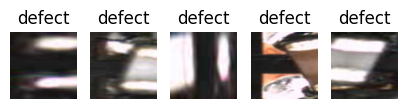

In [ ]:
show_sample_images(train_dataset)



In [ ]:

# Get the total number of samples in the training dataset
print(f"Total number of training samples: {len(train_dataset)}")

# Get the shape of the first image in the dataset
first_image, label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")

Total number of training samples: 172
Shape of the first image: torch.Size([3, 224, 224])


In [ ]:
print(f"Total number of testing samples: {len(test_dataset)}")
first_image, label = test_dataset[0]
print(f"Shape of the first test image: {first_image.shape}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Total number of testing samples: 121
Shape of the first test image: torch.Size([3, 224, 224])


In [ ]:
model = models.vgg19(pretrained=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

from torchsummary import summary
summary(model, input_size=(3, 224, 224))

# Modify final layer
num_classes = len(train_dataset.classes)

model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

model = model.to(device)

summary(model, input_size=(3, 224, 224))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 84.9MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [ ]:
# Freeze feature layers
for param in model.features.parameters():
    param.requires_grad = False

# Define Loss Function
criterion = nn.CrossEntropyLoss()

# Define Optimizer (ONLY classifier parameters)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
## Step 3: Train the Model
def train_model(model, train_loader,test_loader,num_epochs=10):
    train_losses = []
    val_losses = []
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        # Compute validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_losses.append(val_loss / len(test_loader))
        model.train()

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')

    # Plot training and validation loss
    print("Name:  SHIVASRI      ")
    print("Register Number:   212224220098     ")
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

In [ ]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f'Test Accuracy: {accuracy:.4f}')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("Name:  SHIVASRI S      ")
    print("Register Number:  212224220098      ")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print classification report
    print("Name: SHIVASRI       ")
    print("Register Number:  212224220098      ")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Epoch [1/10], Train Loss: 0.9649, Validation Loss: 0.3179
Epoch [2/10], Train Loss: 0.1722, Validation Loss: 0.1877
Epoch [3/10], Train Loss: 0.2398, Validation Loss: 0.1161
Epoch [4/10], Train Loss: 0.0207, Validation Loss: 0.0928
Epoch [5/10], Train Loss: 0.0262, Validation Loss: 0.0954
Epoch [6/10], Train Loss: 0.0067, Validation Loss: 0.1369
Epoch [7/10], Train Loss: 0.0398, Validation Loss: 0.5469
Epoch [8/10], Train Loss: 0.1653, Validation Loss: 1.4415
Epoch [9/10], Train Loss: 0.8110, Validation Loss: 2.9753
Epoch [10/10], Train Loss: 0.0000, Validation Loss: 0.9248
Name:  SHIVASRI      
Register Number:   212224220098     


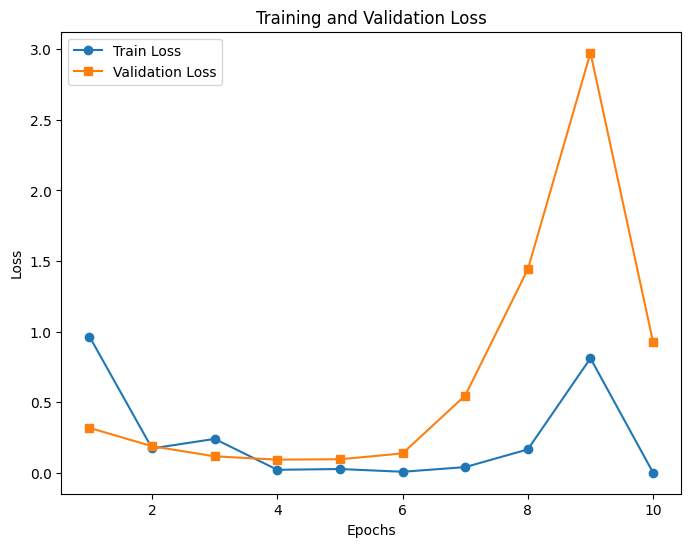

In [ ]:
train_model(model, train_loader, test_loader, num_epochs=10)

Test Accuracy: 0.9256
Name:  SHIVASRI S      
Register Number:  212224220098      


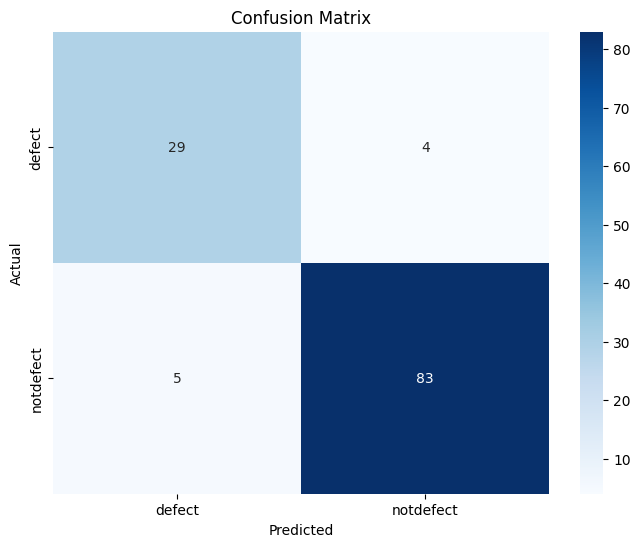

Name: SHIVASRI       
Register Number:  212224220098      
Classification Report:
              precision    recall  f1-score   support

      defect       0.85      0.88      0.87        33
   notdefect       0.95      0.94      0.95        88

    accuracy                           0.93       121
   macro avg       0.90      0.91      0.91       121
weighted avg       0.93      0.93      0.93       121



In [ ]:
test_model(model, test_loader)

In [ ]:
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]

    with torch.no_grad():
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    class_names = dataset.classes

    image_to_display = transforms.ToPILImage()(image)

    plt.figure(figsize=(4, 4))
    plt.imshow(image_to_display)
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()

    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')

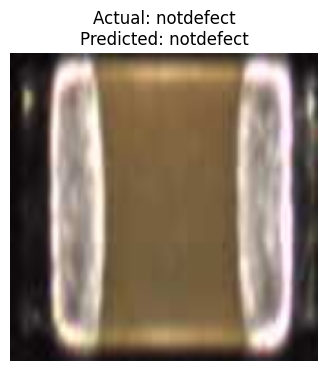

Actual: notdefect, Predicted: notdefect


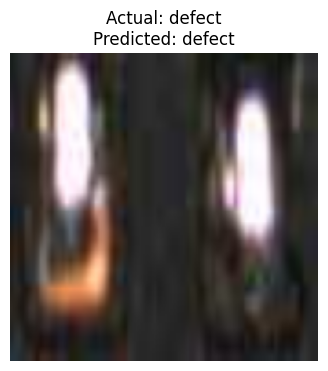

Actual: defect, Predicted: defect


In [ ]:
predict_image(model, image_index=55, dataset=test_dataset)
predict_image(model, image_index=25, dataset=test_dataset)